In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/jfk_weather_cleaned.csv')
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [3]:
print(df.shape)

(75083, 11)


In [4]:
#features with nan values
features_with_nan = [feature for feature in df.columns if df[feature].isnull().sum()>0]
print("features with missing values: ", features_with_nan)
for feature in features_with_nan:
    print(feature, np.round(df[feature].isnull().mean()*100,4), '% missing values')

features with missing values:  []


In [5]:
df.columns

Index(['DATE', 'VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF',
       'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure',
       'SeaLevelPressure', 'Precip'],
      dtype='object')

In [6]:
columns_to_drop = ['WETBULBTEMPF', 'DewPointTempF', 'StationPressure','DATE','Precip']
df.drop(columns=columns_to_drop,axis=1,inplace=True)

In [7]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print("Numerical features: ", len(num_features))
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print("Categorical features: ", len(categorical_features))

Numerical features:  6
Categorical features:  0


In [8]:
discrete_features = [feature for feature in num_features if len(df[feature].unique())<25]
print("Discrete features: ", len(discrete_features),"\ncolumns: ", discrete_features)
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print("Continuous features: ", len(continuous_features),"\ncolumns: ", continuous_features)

Discrete features: 

 1 
columns:  ['VISIBILITY']
Continuous features:  5 
columns:  ['DRYBULBTEMPF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'SeaLevelPressure']


In [9]:
#OUTLIER DETECTION AND TREATMENT
continuous_features

['DRYBULBTEMPF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'SeaLevelPressure']

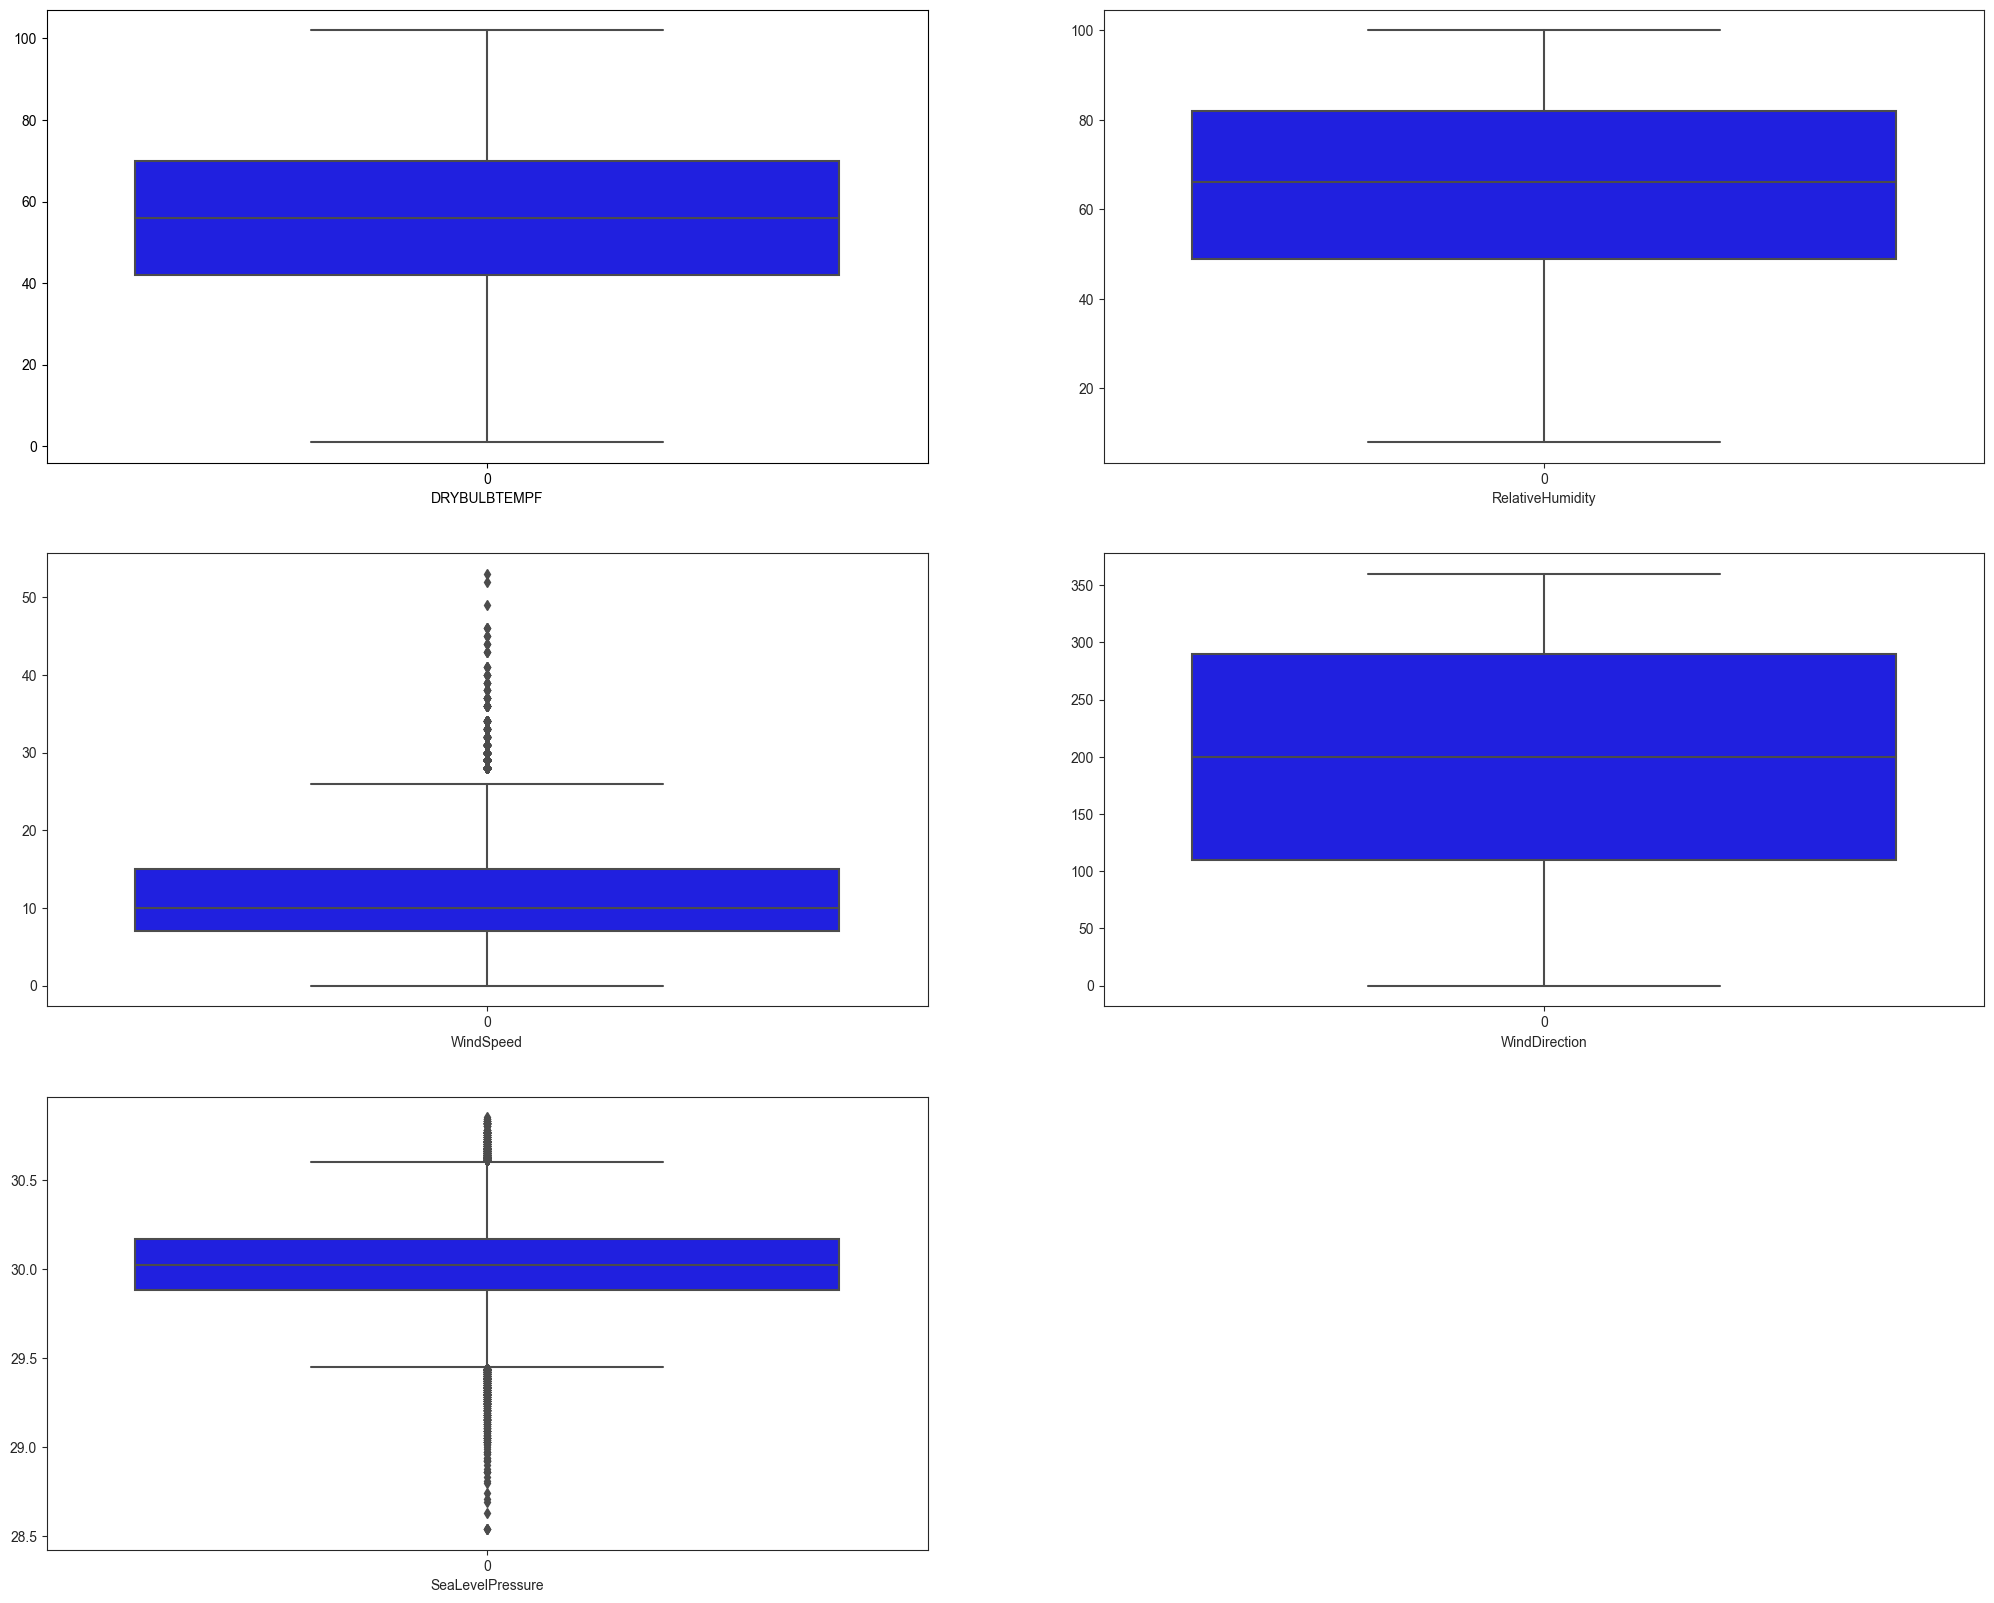

In [10]:
cont_features = continuous_features.copy()
plt.figure(figsize=(25,20))
for i in range(len(cont_features)):
    plt.subplot(3,2,i+1)
    sns.set_style('ticks')
    plt.xlabel(cont_features[i])
    ax = sns.boxplot(df[cont_features[i]],color='blue')

In [11]:
def detect_outliers(col):
    print("\n####",col,"####")
    Q1 = df[col].quantile(0.25)
    print("25th percentile: ", Q1)
    Q3 = df[col].quantile(0.75)
    print("75th percentile: ", Q3)
    IQR = Q3 - Q1
    print("Interquartile Range: ", IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("Lower bound: ", lower_bound)
    print("Upper bound: ", upper_bound)
    df.loc[df[col] < lower_bound, col] = lower_bound
    df.loc[df[col] > upper_bound, col] = upper_bound
    return df

for col in continuous_features:
    detect_outliers(col=col)


#### DRYBULBTEMPF ####
25th percentile:  42.0
75th percentile:  70.0
Interquartile Range:  28.0
Lower bound:  0.0
Upper bound:  112.0

#### RelativeHumidity ####
25th percentile:  49.0
75th percentile:  82.0
Interquartile Range:  33.0
Lower bound:  -0.5
Upper bound:  131.5

#### WindSpeed ####
25th percentile:  7.0
75th percentile:  15.0
Interquartile Range:  8.0
Lower bound:  -5.0
Upper bound:  27.0

#### WindDirection ####
25th percentile:  110.0
75th percentile:  290.0
Interquartile Range:  180.0
Lower bound:  -160.0
Upper bound:  560.0

#### SeaLevelPressure ####
25th percentile:  29.88
75th percentile:  30.17
Interquartile Range:  0.2900000000000027
Lower bound:  29.444999999999993
Upper bound:  30.605000000000004


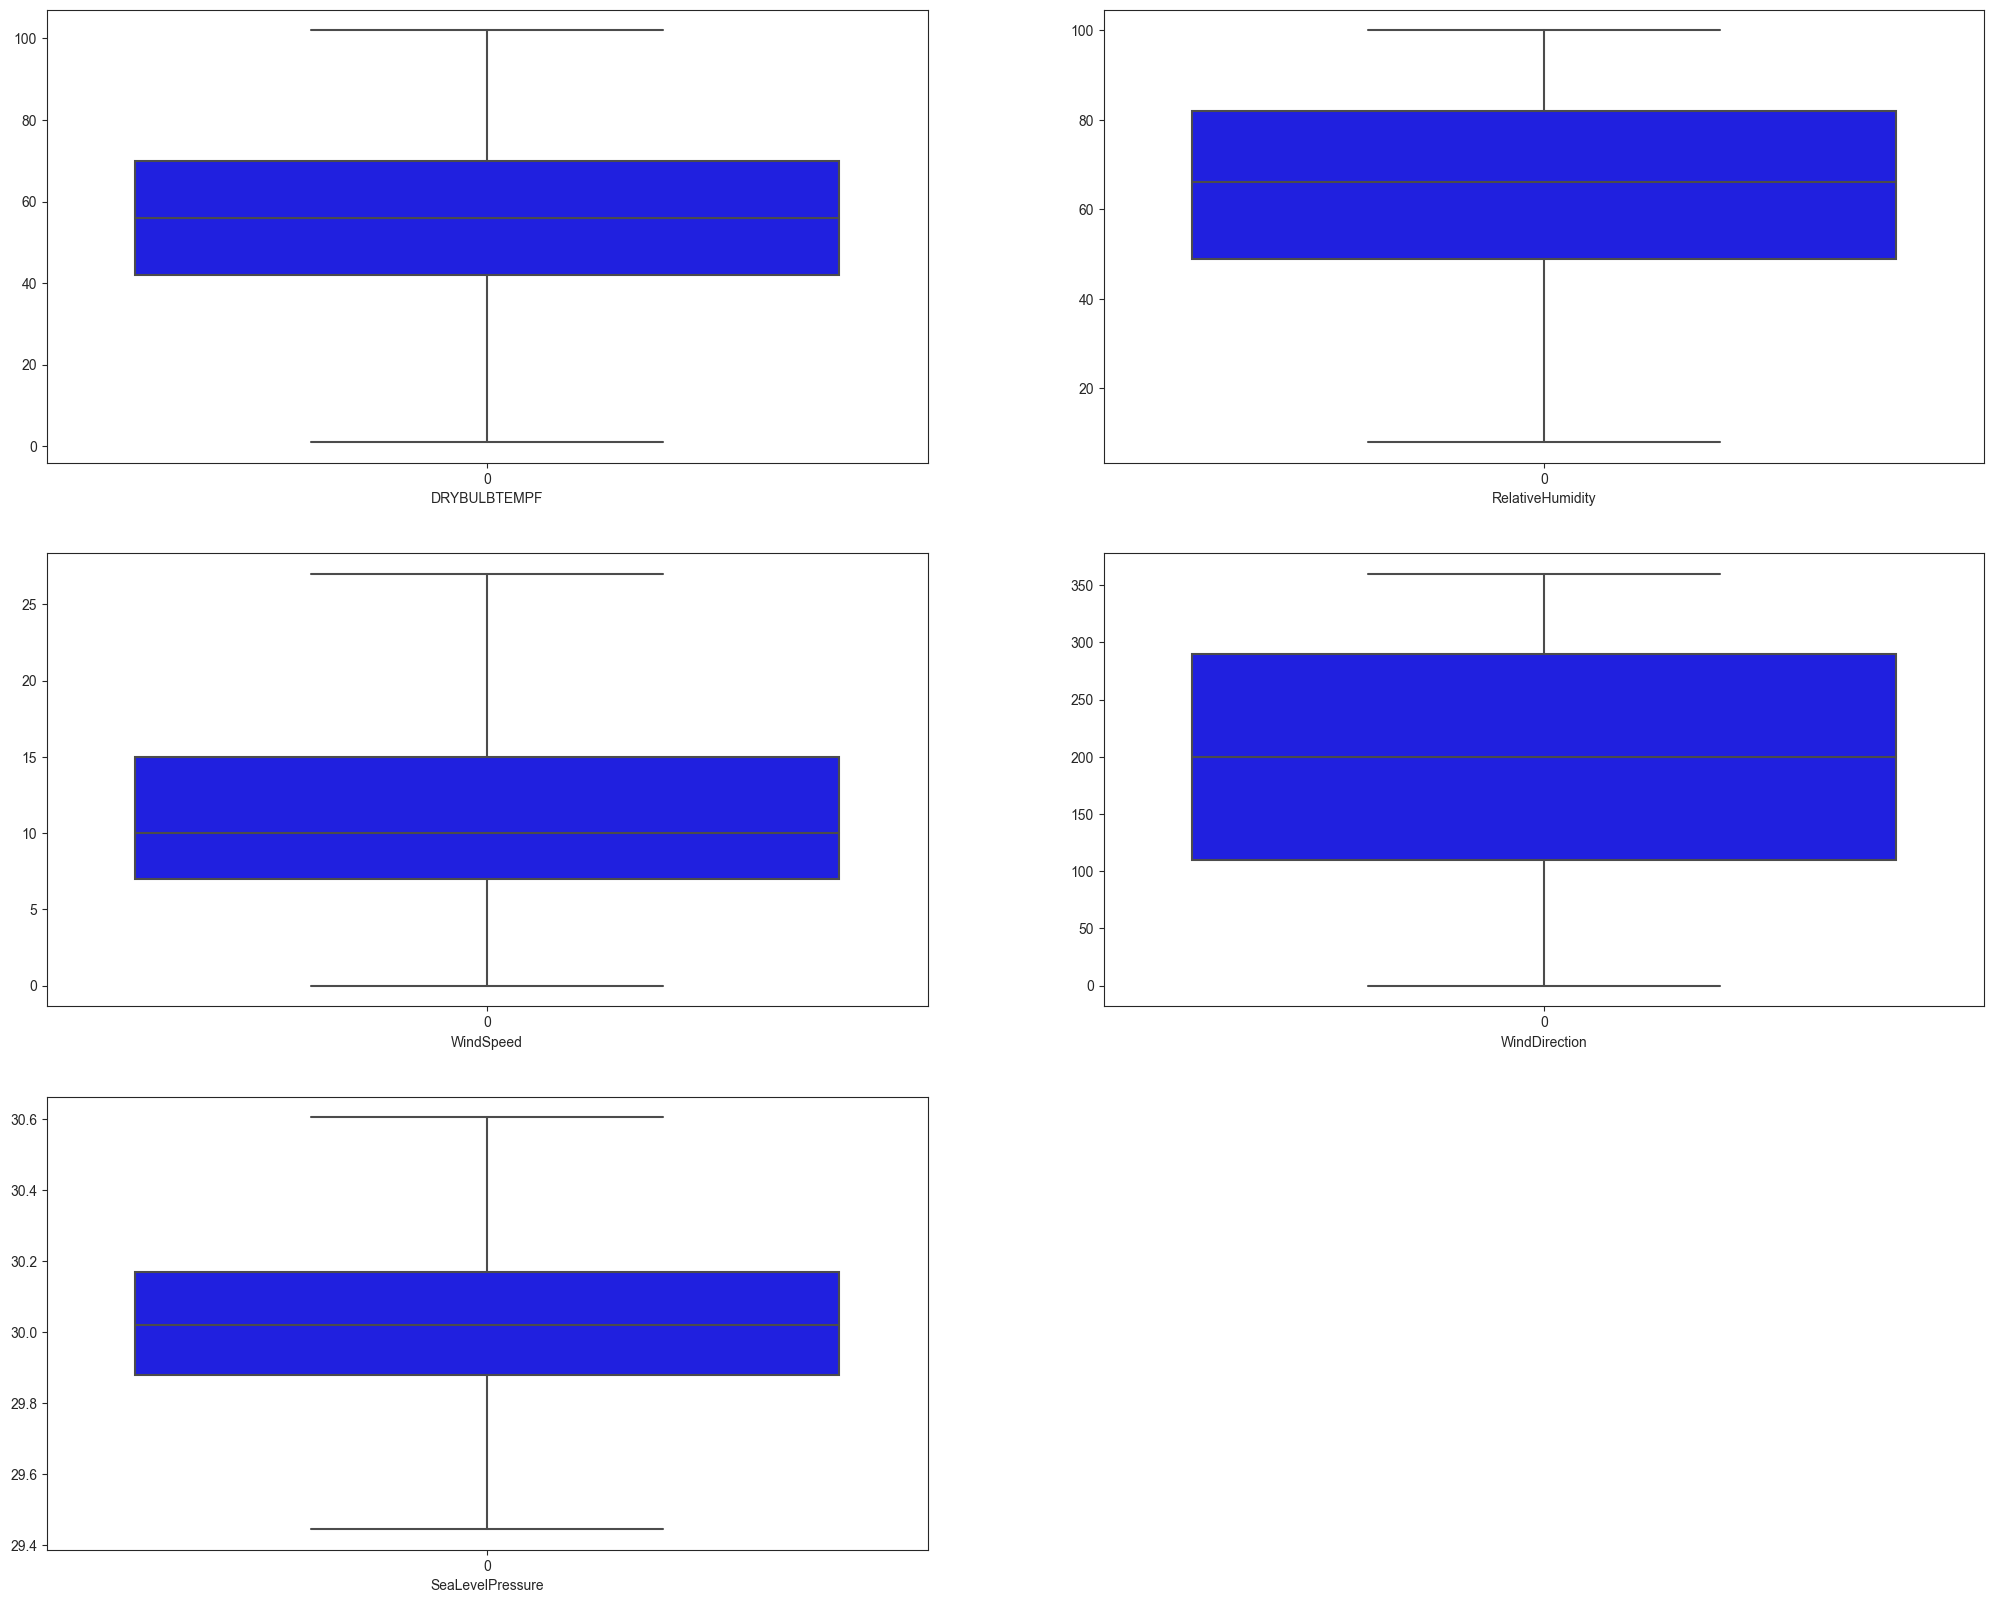

In [12]:
cont_features = continuous_features.copy()
plt.figure(figsize=(25,20))
for i in range(len(cont_features)):
    plt.subplot(3,2,i+1)
    sns.set_style('ticks')
    plt.xlabel(cont_features[i])
    ax = sns.boxplot(df[cont_features[i]],color='blue')

In [13]:
# all the outliers are capped to their respective lower and upper bounds

In [14]:
#Checking skewness of the data
df[continuous_features].skew(axis=0,skipna=True)

DRYBULBTEMPF       -0.149154
RelativeHumidity   -0.186890
WindSpeed           0.471627
WindDirection      -0.335758
SeaLevelPressure    0.005286
dtype: float64

In [15]:
# Clustring through k-means and elbow method

In [16]:
from sklearn.cluster import KMeans

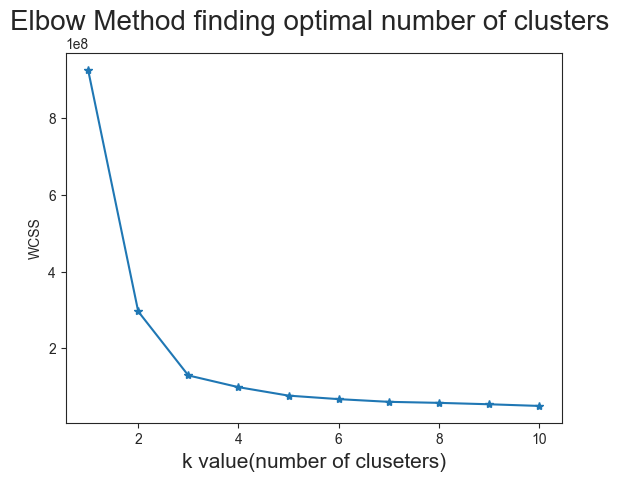

In [17]:
wcss = {}
for i in range(1,11):
    km = KMeans(n_clusters = i)
    km.fit(df)
    wcss[i] = km.inertia_

plt.plot(range(1,11),wcss.values(),marker="*")
plt.title("Elbow Method finding optimal number of clusters ",fontsize=20)
plt.xlabel("k value(number of cluseters)",fontsize=15)
plt.ylabel("WCSS")
plt.show()

In [18]:
# we can observe and decide the optimal number of clusters as 3

In [19]:
from kneed import KneeLocator
def optimal_number_of_clusters(dataframe):
    wcss = []
    try:
        for i in range(1,11):
            kmeans = KMeans(n_clusters = i, init='k-means++', random_state=42)
            kmeans.fit(dataframe)
            wcss.append(kmeans.inertia_)
        kn = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
        print("The optimal number of clusters is: ",kn.knee,". Exited the elbow point method of kmeans clustering class")
        return kn.knee
    except Exception as e:
        print(e)

no_of_clusters = optimal_number_of_clusters(df)
kmeans = KMeans(n_clusters = no_of_clusters)
kmeans.fit(df)
labels = kmeans.predict(df)
df['Clusters'] = labels



The optimal number of clusters is:  3 . Exited the elbow point method of kmeans clustering class


In [25]:
df.tail()

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,Clusters
75078,10.0,76,88.0,3,230,30.02,0
75079,4.0,69,100.0,13,40,30.01,2
75080,10.0,71,96.0,0,0,30.04,2
75081,10.0,72,94.0,5,50,30.02,2
75082,10.0,72,97.0,0,0,30.03,2


In [22]:
df['Clusters'].value_counts()

Clusters
0    29130
1    27013
2    18940
Name: count, dtype: int64

In [26]:
# checking the range of all the features 
df.describe().T[['min','max','mean','std']]

,min,max,mean,std
VISIBILITY,0.000,14.000,9.211896,2.202311
DRYBULBTEMPF,1.000,102.000,55.355527,17.394334
RelativeHumidity,8.000,100.000,64.812075,19.898962
WindSpeed,0.000,27.000,11.204294,5.947034
WindDirection,0.000,360.000,196.550751,107.692804
SeaLevelPressure,29.445,30.605,30.026889,0.227776
Clusters,0.000,2.000,0.864284,0.788552


In [28]:
df.groupby('Clusters').mean()

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure
Clusters,,,,,,
0,9.106739,62.835942,71.656093,10.693134,191.836251,30.016901
1,9.703242,48.325362,52.337541,13.851368,309.008996,29.994293
2,8.672852,53.877244,72.077561,8.215100,43.409187,30.088740


In [35]:
#Apply Standard scaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

train_set,test_set = train_test_split(df,test_size=0.2,random_state=42)
X_train = train_set.drop(columns=['VISIBILITY','Clusters'],axis=1)
y_train = train_set['VISIBILITY']
X_test = test_set.drop(columns=['VISIBILITY','Clusters'],axis=1)
y_test = test_set['VISIBILITY']

preprocessor = StandardScaler()
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [46]:

from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from xgboost.sklearn import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

models = {}
models['Linear Regression'] = LinearRegression()
models['Ridge Regression'] = Ridge()
models['Lasso Regression'] = Lasso()
models['ElasticNet Regression'] = ElasticNet()
models['Decision Tree Regressor'] = DecisionTreeRegressor()
models['Random Forest Regressor'] = RandomForestRegressor()

def select_best_model(models = models, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test):
    model_report = {}
    for name, model in models.items():
        print(f"Training the model: {name}")
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        r2_scr = r2_score(y_test,y_pred)
        model_report[name] = r2_scr
    return model_report

model_details = select_best_model()
model_details


Training the model: Linear Regression
Training the model: Ridge Regression
Training the model: Lasso Regression
Training the model: ElasticNet Regression
Training the model: Decision Tree Regressor
Training the model: Random Forest Regressor


{'Linear Regression': 0.25395113747711484,
 'Ridge Regression': 0.25395109290164697,
 'Lasso Regression': 0.008937836461472948,
 'ElasticNet Regression': 0.12066325363907271,
 'Decision Tree Regressor': 0.2897460860496942,
 'Random Forest Regressor': 0.6008405161147378}

In [39]:
# We can observe that Random Forest Regressor is giving the best R2 score.
# it will be used for hyperparameter tuning and final deployment.